# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.tail(10)

Total experiments: 134
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
124,e959810,1.205659,4.6,DISCARD,try WEIGHT_DECAY 0.06 with ns_steps=4 (worse; ...
125,669ca9f,1.209905,4.6,DISCARD,try Muon momentum target 0.95 in ns_steps=4 re...
126,8036068,1.208600,4.6,DISCARD,try WARMUP_RATIO 0.02 (LR warmup; worse than 0.0)
127,ddc0c38,1.206395,4.6,DISCARD,try x0_lambdas init 0.0 (worse than 0.1)
128,65a7c53,1.209150,4.6,DISCARD,"try VE last layer only (worse; alternating 1,3..."
129,54732bb,1.218947,4.6,DISCARD,"try VE layers 0,2 (worse; layers 1,3 is optimal)"
130,9ded97f,1.222799,4.6,DISCARD,try embedding weight_decay=0.01 (much worse; e...
131,5a86c74,1.215835,4.6,DISCARD,"try depth=4 dim=640 821 steps (fewer steps, wo..."
132,3f87ce0,1.208467,4.6,DISCARD,try 2^14 batch sqrt-scaled LRs (2050 steps; be...
133,aa0a00e,1.206030,4.6,DISCARD,try grad clip max_norm=1.0 (worse; Muon+AdamW ...


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    88
KEEP       43
CRASH       3

Keep rate: 43/131 = 32.8%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (43 total):

  #  3  bpb=1.849848  mem=2.9GB  baseline on this host with compile off, SDPA fallback, batch cap 8, checkpointing on
  #  4  bpb=1.846457  mem=2.9GB  increase Muon matrix LR from 0.04 to 0.06
  #  5  bpb=1.841402  mem=2.9GB  increase Muon matrix LR from 0.06 to 0.08
  #  7  bpb=1.803798  mem=5.3GB  reduce Muon weight decay from 0.2 to 0.15
  #  8  bpb=1.793294  mem=5.3GB  reduce Muon weight decay from 0.15 to 0.10
  # 10  bpb=1.776233  mem=5.3GB  shorten LR warmdown ratio from 0.50 to 0.35
  # 11  bpb=1.771168  mem=5.3GB  shorten LR warmdown ratio from 0.35 to 0.25
  # 12  bpb=1.759871  mem=5.3GB  shorten LR warmdown ratio from 0.25 to 0.15
  # 13  bpb=1.747420  mem=5.3GB  shorten LR warmdown ratio from 0.15 to 0.05
  # 14  bpb=1.738784  mem=5.3GB  set LR warmdown ratio from 0.05 to 0.00
  # 16  bpb=1.731310  mem=5.3GB  keep Muon weight decay constant instead of decaying to zero
  # 17  bpb=1.725902  mem=5.3GB  increase constant Muon weight decay from 0.1

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

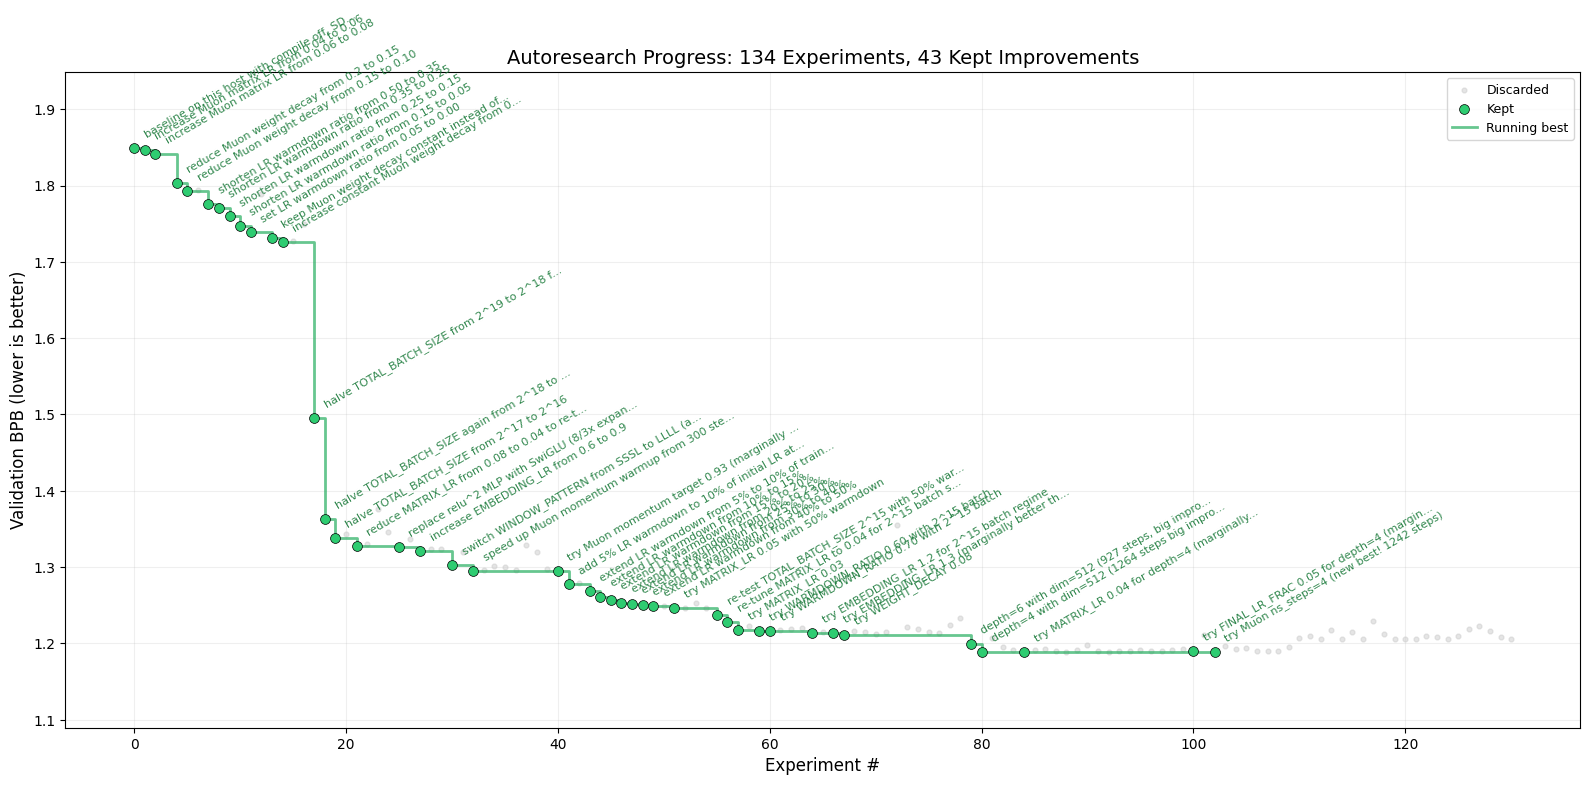

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(
    disc.index,
    disc["val_bpb"],
    c="#cccccc",
    s=12,
    alpha=0.5,
    zorder=2,
    label="Discarded",
)

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(
    kept_v.index,
    kept_v["val_bpb"],
    c="#2ecc71",
    s=50,
    zorder=4,
    label="Kept",
    edgecolors="black",
    linewidths=0.5,
)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(
    kept_idx,
    running_min,
    where="post",
    color="#27ae60",
    linewidth=2,
    alpha=0.7,
    zorder=3,
    label="Running best",
)

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(
        desc,
        (idx, bpb),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8.0,
        color="#1a7a3a",
        alpha=0.9,
        rotation=30,
        ha="left",
        va="bottom",
    )

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(
    f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements",
    fontsize=14,
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()

# Use first successful kept run as baseline (top rows can be crash rows with 0.0 bpb)
baseline_bpb = float(kept.iloc[0]["val_bpb"])
best_bpb = float(kept["val_bpb"].min())
best_row = kept.loc[kept["val_bpb"].idxmin()]

delta = baseline_bpb - best_bpb
improvement_pct = (delta / baseline_bpb * 100.0) if baseline_bpb > 0 else float("nan")

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {delta:.6f} ({improvement_pct:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.849848
Best val_bpb:      1.188698
Total improvement: 0.661150 (35.74%)
Best experiment:   try Muon ns_steps=4 (new best! 1242 steps)

Cumulative effort per improvement:
  Experiment #  3: bpb=1.849848  baseline on this host with compile off, SDPA fallback, batch cap 8, checkpointing on
  Experiment #  4: bpb=1.846457  increase Muon matrix LR from 0.04 to 0.06
  Experiment #  5: bpb=1.841402  increase Muon matrix LR from 0.06 to 0.08
  Experiment #  7: bpb=1.803798  reduce Muon weight decay from 0.2 to 0.15
  Experiment #  8: bpb=1.793294  reduce Muon weight decay from 0.15 to 0.10
  Experiment # 10: bpb=1.776233  shorten LR warmdown ratio from 0.50 to 0.35
  Experiment # 11: bpb=1.771168  shorten LR warmdown ratio from 0.35 to 0.25
  Experiment # 12: bpb=1.759871  shorten LR warmdown ratio from 0.25 to 0.15
  Experiment # 13: bpb=1.747420  shorten LR warmdown ratio from 0.15 to 0.05
  Experiment # 14: bpb=1.738784  set LR warmdown ratio from 0.05 to 0.00
  Experim

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(
    f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline"
)

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.230432  1.495470  halve TOTAL_BATCH_SIZE from 2^19 to 2^18 for more optimizer steps
   2  +0.132763  1.362707  halve TOTAL_BATCH_SIZE again from 2^18 to 2^17
   3  +0.037604  1.803798  reduce Muon weight decay from 0.2 to 0.15
   4  +0.024494  1.338213  halve TOTAL_BATCH_SIZE from 2^17 to 2^16
   5  +0.018230  1.302446  switch WINDOW_PATTERN from SSSL to LLLL (all full attention)
   6  +0.017937  1.277356  add 5% LR warmdown to 10% of initial LR at end of training
   7  +0.017061  1.776233  shorten LR warmdown ratio from 0.50 to 0.35
   8  +0.012833  1.198832  depth=6 with dim=512 (927 steps, big improvement over depth=8)
   9  +0.012451  1.747420  shorten LR warmdown ratio from 0.15 to 0.05
  10  +0.011297  1.759871  shorten LR warmdown ratio from 0.25 to 0.15
  11  +0.010504  1.793294  reduce Muon weight decay from 0.15 to 0.10
  12  +0.010364  1.327849  r